In [1]:
#Importo Librerias. Las versiones son las explicitadas en requirements .txt.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

C:\Users\59892\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\59892\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
dfproductos = pd.read_csv("https://raw.githubusercontent.com/Sebacelesia/GestionDatos/dev/data/dfproductos.csv")
dforders = pd.read_csv("https://raw.githubusercontent.com/Sebacelesia/GestionDatos/dev/data/dforders.csv")
dfclients = pd.read_csv("https://raw.githubusercontent.com/Sebacelesia/GestionDatos/dev/data/dfclientes.csv")

**Elección de target**

<Figure size 720x432 with 0 Axes>

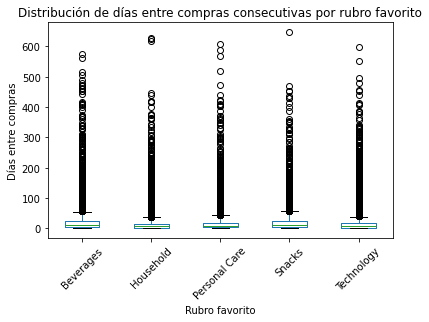

<Figure size 720x432 with 0 Axes>

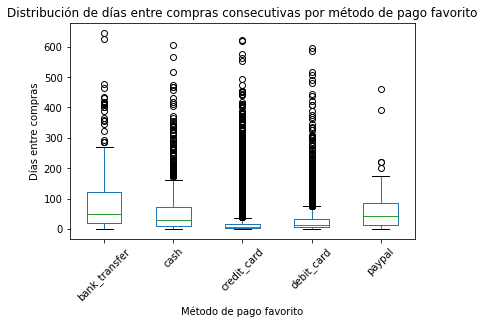

<Figure size 720x432 with 0 Axes>

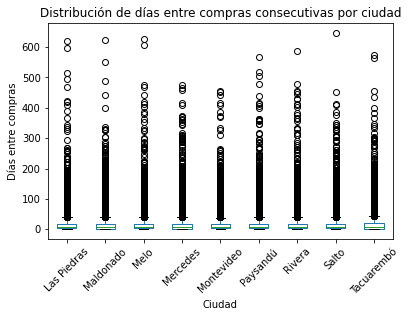

In [8]:
# --- Moda de rubro favorito por cliente ---
rubro_favorito = (
    dforders.groupby('client_id')['product_category']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'product_category': 'rubro_favorito'})
)

# --- Moda de método de pago por cliente ---
payment_favorito = (
    dforders.groupby('client_id')['payment_method']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'payment_method': 'payment_favorito'})
)

# --- Incorporamos ambas al dataframe con diferencias entre compras ---
df_sorted = dforders.sort_values(['client_id', 'order_timestamp'])
df_sorted['diff_dias'] = df_sorted.groupby('client_id')['order_timestamp'].diff().dt.days
df_valid = df_sorted.dropna(subset=['diff_dias'])

# Unimos rubro favorito y método de pago favorito
df_valid = (
    df_valid
    .merge(rubro_favorito, on='client_id', how='left')
    .merge(payment_favorito, on='client_id', how='left')
)

# --- Boxplot por rubro favorito ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_valid.boxplot(column='diff_dias', by='rubro_favorito', grid=False, rot=45)
plt.title('Distribución de días entre compras consecutivas por rubro favorito')
plt.suptitle('')
plt.xlabel('Rubro favorito')
plt.ylabel('Días entre compras')
plt.show()

# --- Boxplot por método de pago favorito ---
plt.figure(figsize=(10, 6))
df_valid.boxplot(column='diff_dias', by='payment_favorito', grid=False, rot=45)
plt.title('Distribución de días entre compras consecutivas por método de pago favorito')
plt.suptitle('')
plt.xlabel('Método de pago favorito')
plt.ylabel('Días entre compras')
plt.show()

# --- Unimos información de ciudad al dataframe de órdenes ---
df_valid = df_valid.merge(
    dfclients[['client_id', 'city']], 
    on='client_id', 
    how='left'
)

# --- Boxplot por ciudad ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_valid.boxplot(column='diff_dias', by='city', grid=False, rot=45)
plt.title('Distribución de días entre compras consecutivas por ciudad')
plt.suptitle('')
plt.xlabel('Ciudad')
plt.ylabel('Días entre compras')
plt.show()


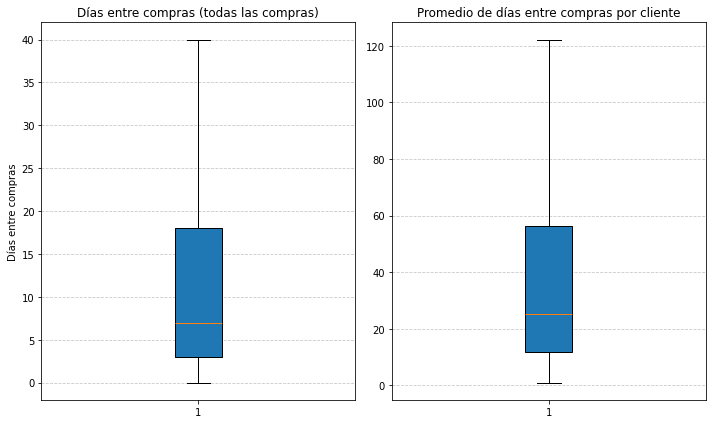

In [51]:
import matplotlib.pyplot as plt

# --- Promedio de días entre compras por cliente ---
promedio_entre_compras = (
    df_valid.groupby('client_id')['diff_dias']
    .mean()
    .reset_index()
    .rename(columns={'diff_dias': 'promedio_entre_compras'})
)

# --- Boxplots lado a lado ---
plt.figure(figsize=(10, 6))

# 1️⃣ Boxplot general (todas las compras)
plt.subplot(1, 2, 1)
plt.boxplot(df_valid['diff_dias'].dropna(), vert=True, patch_artist=True, showfliers=False)
plt.title('Días entre compras (todas las compras)')
plt.ylabel('Días entre compras')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 2️⃣ Boxplot promedio por cliente
plt.subplot(1, 2, 2)
plt.boxplot(promedio_entre_compras['promedio_entre_compras'].dropna(), vert=True, patch_artist=True, showfliers=False)
plt.title('Promedio de días entre compras por cliente')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Como se observa en los boxplots, la mayoría de los clientes repite su compra dentro de un plazo corto: la mediana de los días entre compras se ubica en torno a los 20 días, y el 75 % de los clientes (P75) lo hace antes de los 60 días. A partir de ese punto, los intervalos se vuelven mucho más dispersos y aparecen casos de inactividad prolongada.

Esto sugiere que 60 días representan el límite natural del comportamiento típico de recompra: los clientes que superan ese período tienden a apartarse del patrón habitual y muestran señales claras de desinterés o abandono.
Desde el punto de vista del negocio, este horizonte es suficientemente amplio para evitar falsos positivos (clientes que simplemente demoran un poco más en volver a comprar), pero al mismo tiempo permite detectar tempranamente posibles casos de churn.

En los métodos de pago menos frecuentes —como Bank Transfer o PayPal— se observan intervalos algo mayores, aunque estos casos son poco representativos en el total y no modifican sustancialmente la tendencia general.

**Eleccion de variables**

Las variables RFM se incorporan al modelo porque resumen de forma clara el comportamiento histórico de cada cliente y constituyen una metodología ampliamente utilizada en proyectos de predicción de churn y segmentación de clientes. La recencia mide el tiempo desde la última compra y suele estar directamente asociada al riesgo de abandono, la frecuencia refleja la regularidad de las compras, permitiendo diferenciar clientes fieles de los esporádicos y el valor monetario indica cuánto gasta un cliente en promedio o en total, ayudando a identificar su importancia económica.

Además de las métricas RFM, se incorporaron otras variables que permiten capturar distintos aspectos del comportamiento del cliente y enriquecer el análisis.
En primer lugar, se calcularon estadísticas sobre los intervalos entre compras (Promedio_Días_Compras, Varianza_Días_Compras, Máx y Mín), que reflejan la regularidad y estabilidad del hábito de compra

También se incluyó la antigüedad total del cliente (Tenure_Días), medida como la diferencia entre la primera y la última compra, útil para identificar usuarios con relaciones más duraderas con la empresa.
La Diversidad_Categorías muestra la amplitud de los intereses del cliente dentro del catálogo, mientras que las modas de categoría, método de pago y método de envío aportan información sobre sus preferencias predominantes.
El Ticket_Promedio y su desvío estándar ayudan a comprender el nivel de gasto y la variabilidad en los montos, factores asociados a la estabilidad del comportamiento de compra.
Por otro lado, el número de compras recientes en los últimos 30 y 90 días sirve para identificar actividad actual, un indicador clave de retención. Finalmente, el Promedio_Shipping_Cost resume el gasto medio en envíos, que puede vincularse al tipo de productos adquiridos o a la disposición del cliente a pagar por conveniencia.


In [52]:
import pandas as pd

dforders['order_timestamp'] = pd.to_datetime(dforders['order_timestamp'])
dfclients['registration_date'] = pd.to_datetime(dfclients['registration_date'], errors='coerce')
dfclients['last_seen'] = pd.to_datetime(dfclients['last_seen'], errors='coerce')

# --- FECHA DE REFERENCIA (día siguiente al último pedido) ---
fecha_max = dforders['order_timestamp'].max()
fecha_corte = fecha_max - pd.Timedelta(days=60)   # horizonte: 60 días antes del último pedido
fecha_ref = fecha_corte + pd.Timedelta(days=1)

# --- DIVIDIMOS EN PERÍODO HISTÓRICO Y PERÍODO FUTURO ---
df_hist = dforders[dforders['order_timestamp'] <= fecha_corte].copy()
df_futuro = dforders[dforders['order_timestamp'] > fecha_corte].copy()

# -----------------------------------------------------------------
#                   FEATURES HISTÓRICAS (hasta fecha_corte)
# -----------------------------------------------------------------

# --- RFM ---
rfm = (
    df_hist.groupby('client_id')
    .agg({
        'order_timestamp': lambda x: (fecha_ref - x.max()).days,  # Recency
        'order_id': 'count',                                     # Frequency
        'order_price': 'sum'                                     # Monetary
    })
    .rename(columns={
        'order_timestamp': 'Recency_Dias',
        'order_id': 'Frequency',
        'order_price': 'Monetary'
    })
    .reset_index()
)

# --- Días promedio y varianza entre compras ---
 = (
    df_hist.sort_values(['client_id', 'order_timestamp'])
    .groupby('client_id')['order_timestamp']
    .apply(lambda x: x.diff().dt.days)
    .reset_index()
    .groupby('client_id')['order_timestamp']
    .agg(['mean', 'std', 'max', 'min'])
    .reset_index()
    .rename(columns={
        'mean': 'Promedio_Dias_Compras',
        'std': 'Varianza_Dias_Compras',
        'max': 'Max_Dias_Entre_Compras',
        'min': 'Min_Dias_Entre_Compras'
    })
)

# --- Tenure (antigüedad total) ---
tenure = (
    df_hist.groupby('client_id')['order_timestamp']
    .agg(['min', 'max'])
    .reset_index()
)
tenure['Tenure_Dias'] = (tenure['max'] - tenure['min']).dt.days
tenure = tenure[['client_id', 'Tenure_Dias']]

# --- Diversidad de categorías ---
diversidad = (
    df_hist.groupby('client_id')['product_category']
    .nunique()
    .reset_index(name='Diversidad_Categorias')
)

# --- Moda de categoría, método de pago y envío ---
moda_categoria = df_hist.groupby('client_id')['product_category'].agg(lambda x: x.mode()[0]).reset_index(name='Moda_Categoria')
moda_payment = df_hist.groupby('client_id')['payment_method'].agg(lambda x: x.mode()[0]).reset_index(name='Moda_Payment')
moda_shipping = df_hist.groupby('client_id')['shipping_method'].agg(lambda x: x.mode()[0]).reset_index(name='Moda_Shipping')

# --- Ticket promedio y variabilidad ---
ticket_stats = (
    df_hist.groupby('client_id')['order_price']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'Ticket_Promedio', 'std': 'Ticket_Desvio'})
)

# --- Compras recientes (últimos 30 y 90 días respecto al corte) ---
df_hist['dias_hasta_ref'] = (fecha_ref - df_hist['order_timestamp']).dt.days
compras_recientes = (
    df_hist.assign(
        ult30=lambda x: x['dias_hasta_ref'] <= 30,
        ult90=lambda x: x['dias_hasta_ref'] <= 90
    )
    .groupby('client_id')
    .agg({'ult30': 'sum', 'ult90': 'sum'})
    .reset_index()
    .rename(columns={'ult30': 'Compras_Ultimos30', 'ult90': 'Compras_Ultimos90'})
)

# --- Promedio del costo de envío ---
prom_shipping = df_hist.groupby('client_id')['shipping_cost'].mean().reset_index(name='Promedio_Shipping_Cost')

# --- Puntajes RFM (normalizados en quintiles) ---
rfm['R_Score'] = pd.qcut(rfm['Recency_Dias'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# -----------------------------------------------------------------
#                   DEFINICIÓN DEL TARGET (CHURN)
# -----------------------------------------------------------------

# Última compra antes del corte
ultima_compra = (
    df_hist.groupby('client_id')['order_timestamp']
    .max()
    .reset_index()
    .rename(columns={'order_timestamp': 'ultima_compra'})
)

# Compras posteriores (para ver quién volvió a comprar)
compras_post = (
    df_futuro.groupby('client_id')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'compras_post'})
)

# Merge y flag de churn
df_churn = ultima_compra.merge(compras_post, on='client_id', how='left')
df_churn['compras_post'] = df_churn['compras_post'].fillna(0)
df_churn['churn'] = (df_churn['compras_post'] == 0).astype(int)

# -----------------------------------------------------------------
#                   DATASET FINAL ANALÍTICO
# -----------------------------------------------------------------

dataset = (
    rfm
    .merge(dfclients, on='client_id', how='left')
    .merge(diff_stats, on='client_id', how='left')
    .merge(tenure, on='client_id', how='left')
    .merge(diversidad, on='client_id', how='left')
    .merge(moda_categoria, on='client_id', how='left')
    .merge(moda_payment, on='client_id', how='left')
    .merge(moda_shipping, on='client_id', how='left')
    .merge(ticket_stats, on='client_id', how='left')
    .merge(compras_recientes, on='client_id', how='left')
    .merge(prom_shipping, on='client_id', how='left')
    .merge(df_churn[['client_id', 'churn']], on='client_id', how='left')
)

In [53]:
dataset = dataset.drop(columns=['first_name', 'last_name', 'email', 'address', 'postal_code','document_type','document_number','document_number',
         ], errors='ignore')

dataset.columns

Index(['client_id', 'Recency_Dias', 'Frequency', 'Monetary', 'R_Score',
       'F_Score', 'M_Score', 'RFM_Score', 'gender', 'age', 'city', 'country',
       'citizenship', 'registration_date', 'last_seen',
       'Promedio_Dias_Compras', 'Varianza_Dias_Compras',
       'Max_Dias_Entre_Compras', 'Min_Dias_Entre_Compras', 'Tenure_Dias',
       'Diversidad_Categorias', 'Moda_Categoria', 'Moda_Payment',
       'Moda_Shipping', 'Ticket_Promedio', 'Ticket_Desvio',
       'Compras_Ultimos30', 'Compras_Ultimos90', 'Promedio_Shipping_Cost',
       'churn'],
      dtype='object')

**Analisis de correlaciones**

El mapa de calor muestra las correlaciones entre todas las variables numéricas incluidas en el dataset. En primer lugar, se destacan las relaciones esperables dentro del modelo RFM. La variable Recency presenta una correlación negativa fuerte con Frequency y Monetary, lo que indica que los clientes que compran con mayor frecuencia o gastan más suelen haber realizado compras más recientes. A su vez, Frequency y Monetary mantienen una correlación positiva alta, reflejando que quienes compran más veces tienden también a gastar más en total.

También se observa una correlación negativa entre Tenure y Recency, lo cual indica que los clientes con mayor antigüedad suelen haber comprado más recientemente. Este patrón es consistente con la idea de que quienes mantienen una relación prolongada con la empresa tienden a permanecer activos y presentan un menor riesgo de abandono.

Las variables relacionadas con los intervalos entre compras (promedio, varianza, máximo y mínimo) muestran correlaciones moderadas con Recency y Frequency, ya que describen la regularidad y estabilidad del comportamiento de compra. Por su parte, la Diversidad de categorías, el Ticket promedio, y las compras recientes en los últimos 30 y 90 días aportan información complementaria, con correlaciones más bajas respecto a las métricas RFM, lo que las convierte en variables valiosas para enriquecer el modelo sin generar multicolinealidad.

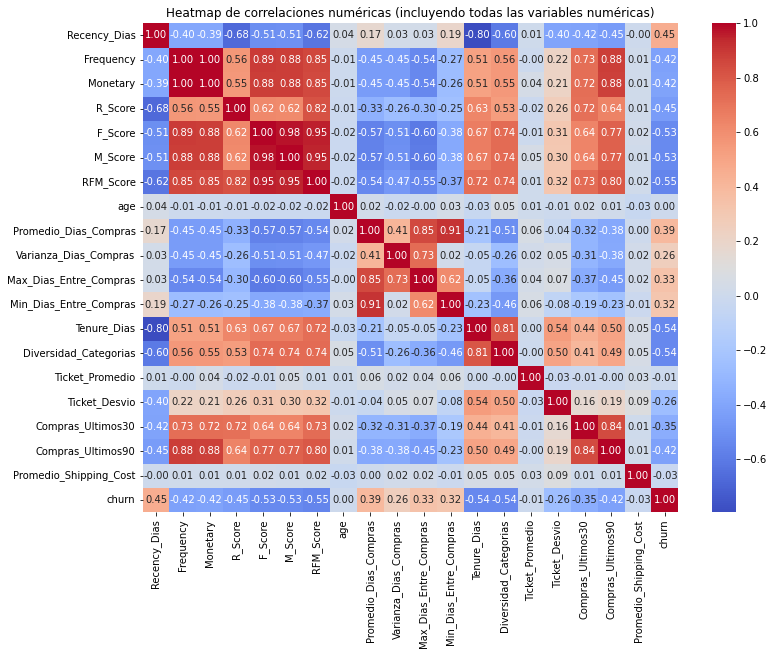

In [54]:
dataset['F_Score'] = dataset['F_Score'].astype('int')
dataset['M_Score'] = dataset['M_Score'].astype('int')

num_df = dataset.select_dtypes(include=[np.number]).drop(columns=['client_id'], errors='ignore')

num_df = num_df.fillna(0)

# --- Heatmap de correlaciones ---
plt.figure(figsize=(12, 9))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de correlaciones numéricas (incluyendo todas las variables numéricas)")
plt.show()


C:\Users\59892\AppData\Local\Temp\ipykernel_10376\584973683.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='F_Score', y='Promedio_Dias_Compras', data=dataset, palette='Blues')
C:\Users\59892\AppData\Local\Temp\ipykernel_10376\584973683.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='M_Score', y='Promedio_Dias_Compras', data=dataset, palette='Greens')
C:\Users\59892\AppData\Local\Temp\ipykernel_10376\584973683.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='F_Score', y='Recency_Dias', data=dataset, palette='Oranges')
C:

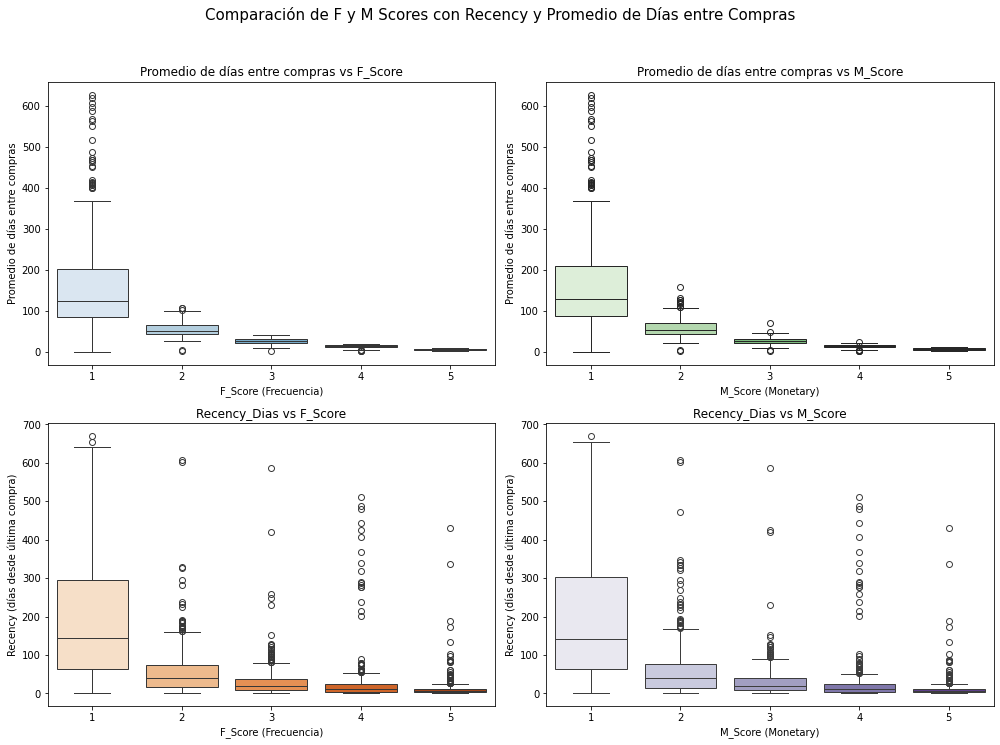

In [55]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='F_Score', y='Promedio_Dias_Compras', data=dataset, palette='Blues')
plt.title('Promedio de días entre compras vs F_Score')
plt.xlabel('F_Score (Frecuencia)')
plt.ylabel('Promedio de días entre compras')

plt.subplot(2, 2, 2)
sns.boxplot(x='M_Score', y='Promedio_Dias_Compras', data=dataset, palette='Greens')
plt.title('Promedio de días entre compras vs M_Score')
plt.xlabel('M_Score (Monetary)')
plt.ylabel('Promedio de días entre compras')

plt.subplot(2, 2, 3)
sns.boxplot(x='F_Score', y='Recency_Dias', data=dataset, palette='Oranges')
plt.title('Recency_Dias vs F_Score')
plt.xlabel('F_Score (Frecuencia)')
plt.ylabel('Recency (días desde última compra)')

plt.subplot(2, 2, 4)
sns.boxplot(x='M_Score', y='Recency_Dias', data=dataset, palette='Purples')
plt.title('Recency_Dias vs M_Score')
plt.xlabel('M_Score (Monetary)')
plt.ylabel('Recency (días desde última compra)')

plt.suptitle('Comparación de F y M Scores con Recency y Promedio de Días entre Compras', fontsize=15, y=1.03)

plt.tight_layout()
plt.show()


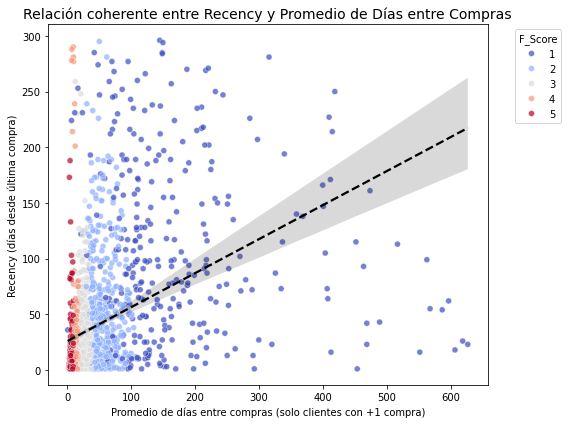

In [56]:
subset = dataset[
    (dataset['Promedio_Dias_Compras'] > 0) &
    (dataset['Recency_Dias'] <= 300)
]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=subset,
    x='Promedio_Dias_Compras',
    y='Recency_Dias',
    hue='F_Score',
    palette='coolwarm',
    alpha=0.7
)
sns.regplot(
    data=subset,
    x='Promedio_Dias_Compras',
    y='Recency_Dias',
    scatter=False,
    color='black',
    line_kws={'linestyle':'--'}
)

plt.title('Relación coherente entre Recency y Promedio de Días entre Compras', fontsize=14)
plt.xlabel('Promedio de días entre compras (solo clientes con +1 compra)')
plt.ylabel('Recency (días desde última compra)')
plt.legend(title='F_Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [57]:
dataset.head()

,client_id,Recency_Dias,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,gender,age,...,Diversidad_Categorias,Moda_Categoria,Moda_Payment,Moda_Shipping,Ticket_Promedio,Ticket_Desvio,Compras_Ultimos30,Compras_Ultimos90,Promedio_Shipping_Cost,churn
0,00094d4c-1acd-46ec-a6d2-c35710c31005,189,2,133.85,1,1,1,3,F,23,...,2,Snacks,credit_card,standard,66.925000,16.638223,0,0,6.075000,1
1,0016d161-d6a2-42f3-bfd6-66aee6d163e3,480,4,235.11,1,1,1,3,F,49,...,2,Beverages,debit_card,standard,58.777500,36.255436,0,0,7.157500,1
2,0042e01f-9154-45fd-9c1d-499b3eb3f1c4,6,72,3626.60,4,5,5,14,F,44,...,5,Household,credit_card,standard,50.369444,28.968426,3,9,5.625694,0
3,0052b716-46cf-4540-aa23-409642dc4048,2,63,3335.50,5,5,5,15,F,31,...,5,Beverages,credit_card,standard,52.944444,28.036658,2,7,5.375714,0
4,00679c7c-bd80-4a70-9052-830bc5b63ecf,1,75,4414.55,5,5,5,15,M,26,...,5,Technology,credit_card,standard,58.860667,22.508065,3,7,5.151333,0


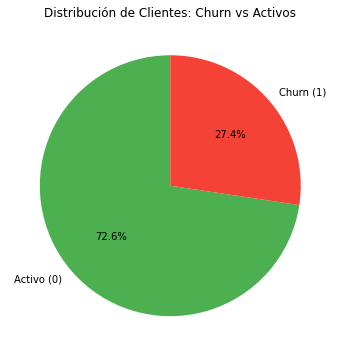

In [58]:
churn_counts = dataset['churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['Activo (0)', 'Churn (1)'], autopct='%1.1f%%', startangle=90, colors=['#4CAF50','#F44336'])
plt.title('Distribución de Clientes: Churn vs Activos')
plt.show()